In [76]:
import matplotlib.pyplot as plt
import numpy as np
from pytket.circuit import Circuit
from pytket.extensions.offline_display import render_circuit_jupyter
from tqdm.auto import tqdm


def add_x_evolution(
    c: Circuit,
    q: int,
    h: float,
    dt: float,
    t_qbit: int 
) -> None:
    angle_x = (-2.0 * h * dt) / np.pi
    c.XXPhase(angle_x, q, t_qbit)

# X^2 = I
def add_zz_evolution(
    c: Circuit,
    q0: int,
    q1: int,
    J: float,
    dt: float,
) -> None:
    angle_zz = (-2.0 * J * dt) / np.pi
    c.CX(q0, q1)
    c.Rz(angle_zz, q1)
    c.CX(q0, q1)

def initialize_iceberg_state(c: Circuit, n_logical: int) -> None:
    a1_qbit = n_logical + 2

    t_qbit = 0
    b_qbit = n_logical + 1

    syndrome_bit_1 = n_logical + 2

    c.H(t_qbit)
    for q in range(t_qbit + 1, b_qbit):
        c.CX(q - 1, q)
    c.CX(t_qbit, a1_qbit)
    c.CX(b_qbit, a1_qbit)

    c.Measure(a1_qbit, syndrome_bit_1)
    c.Reset(a1_qbit)

def measure_syndrome(c: Circuit, n_logical: int) -> None:

    a1_qbit = n_logical + 2
    a2_qbit = n_logical + 3

    t_qbit = 0
    b_qbit = n_logical + 1

    syndrome_bit_1 = n_logical + 2
    syndrome_bit_2 = n_logical + 3

    c.H(a2_qbit)

    def A_block(q1: int):
        c.CX(a2_qbit, q1)
        c.CX(q1, a1_qbit)
        c.CX(q1 + 1, a1_qbit)
        c.CX(a2_qbit, q1 + 1)

    def B_block(q1: int):
        c.CX(a2_qbit, q1)
        c.CX(q1, a1_qbit)
        c.CX(a2_qbit, q1 + 1)
        c.CX(q1 + 1, a1_qbit)


    # A block
    A_block(t_qbit)

    # B blocks

    for q in range(2,(n_logical // 2) - 1, 2):
        B_block(2 + q)

    # A block
    A_block(t_qbit + (n_logical // 2) - 1)
    
    c.H(a2_qbit)


    c.Measure(a1_qbit, syndrome_bit_1)
    c.Measure(a2_qbit, syndrome_bit_2)


def measure_circuit(c: Circuit, n_logical: int) -> None:

    a1_qbit = n_logical + 2
    a2_qbit = n_logical + 3

    t_qbit = 0
    b_qbit = n_logical + 1

    syndrome_bit_1 = n_logical + 2
    syndrome_bit_2 = n_logical + 3

    c.CX(a1_qbit, t_qbit)
    c.CX(a1_qbit, a2_qbit)

    for q in range(t_qbit + 1,  b_qbit - 1):
        c.CX(a1_qbit, q)
    

    c.CX(a1_qbit, a2_qbit)
    c.CX(a1_qbit, b_qbit)

    c.H(a1_qbit)

    c.Measure(a1_qbit, syndrome_bit_1)
    c.Measure(a2_qbit, syndrome_bit_2)

    c.measure_all()



def build_trotter_step(
    c: Circuit,
    h: float,
    J: float,
    dt: float,
    n_logical: int,
) -> None:
    for q in range(1, n_logical + 1):
        add_x_evolution(c, q, h, dt, 0)

    for q in range(1, n_logical):
        add_zz_evolution(c, q, q + 1, J, dt)



def build_trotter_circuit(
    h: float,
    J: float,
    t: float,
    steps: int,
    n_qbits: int,
) -> Circuit:
    dt = float(t) / int(steps)
    logic_qbits = n_qbits
    physical_qbits = logic_qbits + 4
    circuit = Circuit(physical_qbits, physical_qbits)
    initialize_iceberg_state(circuit, logic_qbits)
    circuit.add_barrier(range(physical_qbits))

    for i in range(int(steps)):
        build_trotter_step(circuit, h, J, dt, logic_qbits)
        if i == int(steps) // 2:

            circuit.add_barrier(range(physical_qbits))
            measure_syndrome(circuit, logic_qbits)
            circuit.add_barrier(range(physical_qbits))

    circuit.add_barrier(range(physical_qbits))
    measure_circuit(circuit, logic_qbits)

    return circuit


In [77]:
circuit = build_trotter_circuit(
    h=1.0,
    J=1.0,
    t=1.0,
    steps=1,
    n_qbits=2
    )

render_circuit_jupyter(circuit)

In [78]:
import qnexus as qnx
qnx.login()
project = qnx.projects.get_or_create(
    name="Hackathon project",
)
qnx.context.set_active_project(project)

Already logged in. Tokens are valid.


In [79]:
import json
from pathlib import Path

from pytket.backends.backendresult import BackendResult


n_qbits = 8
DYNAMICS_SHOTS = 10_000
QNEXUS_RUNS_DIR = Path.cwd() / "qnexus_runs"

config = qnx.QuantinuumConfig(
    device_name="H2-Emulator",
)


def prepare_run_directory(run_label, run_suffix, scan_records):
    run_root = QNEXUS_RUNS_DIR / run_label
    run_directory = run_root / run_suffix
    run_directory.mkdir(parents=True, exist_ok=False)

    (run_directory / "scan_records.json").write_text(
        json.dumps(scan_records, indent=2),
        encoding="utf-8",
    )
    (run_root / "latest_run.txt").write_text(
        str(run_directory.resolve()),
        encoding="utf-8",
    )
    return run_directory


def latest_run_directory(run_label, required=True):
    pointer = QNEXUS_RUNS_DIR / run_label / "latest_run.txt"
    if not pointer.exists():
        if required:
            raise FileNotFoundError(
                f"No existe una ejecución guardada para {run_label!r}."
            )
        return None

    run_directory = Path(pointer.read_text(encoding="utf-8").strip())
    if not run_directory.exists():
        raise FileNotFoundError(
            f"El directorio guardado no existe: {run_directory}"
        )
    return run_directory


def save_job_reference(job_reference, path):
    qnx.filesystem.save(
        ref=job_reference,
        path=Path(path),
        mkdir=True,
    )


def load_scan_records(run_directory):
    return json.loads(
        (Path(run_directory) / "scan_records.json").read_text(
            encoding="utf-8"
        )
    )


def recover_execution_records(run_directory):
    run_directory = Path(run_directory)
    execute_path = run_directory / "execute-job"
    if not execute_path.exists():
        raise FileNotFoundError(
            f"No existe una referencia de ejecución en {run_directory}."
        )

    execute_job = qnx.filesystem.load(path=execute_path)
    job_status = qnx.jobs.status(execute_job)
    status_value = getattr(
        job_status.status,
        "value",
        str(job_status.status),
    )
    if status_value != "COMPLETED":
        raise RuntimeError(
            f"El job no está completo: {status_value}. "
            "Revisa su estado antes de recuperar resultados."
        )

    result_refs = qnx.jobs.results(execute_job)
    scan_records = load_scan_records(run_directory)
    if len(result_refs) != len(scan_records):
        raise RuntimeError(
            f"Se encontraron {len(result_refs)} resultados para "
            f"{len(scan_records)} registros."
        )

    cache_directory = run_directory / "result_cache"
    cache_directory.mkdir(exist_ok=True)
    backend_results = []

    for index, result_ref in enumerate(
        tqdm(
            result_refs,
            desc="Recuperando resultados",
            unit="resultado",
        )
    ):
        cache_path = cache_directory / f"{index:04d}.json"
        if cache_path.exists():
            backend_result = BackendResult.from_dict(
                json.loads(cache_path.read_text(encoding="utf-8"))
            )
        else:
            backend_result = result_ref.download_result()
            temporary_path = cache_path.with_suffix(".tmp")
            temporary_path.write_text(
                json.dumps(backend_result.to_dict()),
                encoding="utf-8",
            )
            temporary_path.replace(cache_path)
        backend_results.append(backend_result)

    return [
        {**record, "backend_result": backend_result}
        for record, backend_result in zip(
            scan_records,
            backend_results,
            strict=True,
        )
    ]


In [80]:
import datetime

def generate_tfim_trotter_scan(
    hj_ratios,
    times,
    J=1.0,
    steps=100,
    n=8,
    measure=True,
    name_prefix="tfim",
):
    """
    Genera todos los circuitos del barrido TFIM.

    El orden de salida es ratio -> tiempo. Ese orden es el que usan
    las celdas de simulacion local y las graficas posteriores.
    """
    jobname_suffix = datetime.datetime.now().strftime("%Y_%m_%d-%H_%M_%S")
    ratios = np.asarray(hj_ratios, dtype=float)
    times = np.asarray(times, dtype=float)

    circuits = []
    scan_records = []

    for ratio_index, ratio in enumerate(ratios):
        for time_index, t in enumerate(times):
            circuit_index = len(circuits)
            circuit_name = f"{name_prefix}-{jobname_suffix}-{circuit_index}"

            circuit = build_trotter_circuit(
                h=ratio * J,
                J=J,
                t=t,
                steps=steps,
                n_qbits=n,
            )
            if measure:
                circuit.measure_all()

            circuits.append(circuit)
            scan_records.append(
                {
                    "index": circuit_index,
                    "ratio_index": ratio_index,
                    "time_index": time_index,
                    "ratio": float(ratio),
                    "time": float(t),
                    "J": float(J),
                    "steps": int(steps),
                    "dt": float(t / steps),
                    "n": int(n),
                    "name": circuit_name,
                }
            )

    return circuits, scan_records, jobname_suffix

In [81]:
hj_ratios = np.array([2.0])
times_simulator = np.linspace(0, 1, 25)
times_simulator = times_simulator[times_simulator > 0.0]
J = 1.0
steps = 25
n = n_qbits

DYNAMICS_RUN_LABEL = "h2-noise-dynamics-n8-s25"
FORCE_NEW_DYNAMICS_RUN = False

dynamics_run_dir = (
    None
    if FORCE_NEW_DYNAMICS_RUN
    else latest_run_directory(DYNAMICS_RUN_LABEL, required=False)
)
has_saved_job = (
    dynamics_run_dir is not None
    and (
        (dynamics_run_dir / "compile-job").exists()
        or (dynamics_run_dir / "execute-job").exists()
    )
)

if has_saved_job:
    print(f"Reutilizando ejecución H2: {dynamics_run_dir}")
else:
    circuits, scan_records, jobname_suffix = generate_tfim_trotter_scan(
        hj_ratios=hj_ratios,
        times=times_simulator,
        J=J,
        steps=steps,
        n=n,
        measure=True,
        name_prefix="tfim-h2-noise-dynamics",
    )
    dynamics_run_dir = prepare_run_directory(
        DYNAMICS_RUN_LABEL,
        jobname_suffix,
        scan_records,
    )
    circuit_refs = [
        qnx.circuits.upload(
            circuit=circuit,
            name=record["name"],
        )
        for circuit, record in tqdm(
            zip(circuits, scan_records, strict=True),
            total=len(circuits),
            desc="Subiendo circuitos H2-noise",
            unit="circuito",
        )
    ]


Reutilizando ejecución H2: /Users/anotherdev/workspace/quanthathon/project/qnexus_runs/h2-noise-dynamics-n8-s25/2026_07_23-15_19_07


In [82]:
compile_path = dynamics_run_dir / "compile-job"
execute_path = dynamics_run_dir / "execute-job"

if execute_path.exists():
    print("La ejecución H2 ya está guardada.")
elif compile_path.exists():
    ref_compile_job = qnx.filesystem.load(path=compile_path)
    qnx.jobs.wait_for(ref_compile_job)
    print("Compilación H2 recuperada.")
else:
    ref_compile_job = qnx.start_compile_job(
        programs=circuit_refs,
        backend_config=config,
        optimisation_level=2,
        name=f"h2-noise-dynamics-compile-{dynamics_run_dir.name}",
        project=project,
    )
    save_job_reference(ref_compile_job, compile_path)
    qnx.jobs.wait_for(ref_compile_job)


La ejecución H2 ya está guardada.


In [83]:
execute_path = dynamics_run_dir / "execute-job"

if execute_path.exists():
    my_execute_job_ref = qnx.filesystem.load(path=execute_path)
    qnx.jobs.wait_for(my_execute_job_ref)
    print("Ejecución H2 recuperada.")
else:
    ref_compile_job = qnx.filesystem.load(
        path=dynamics_run_dir / "compile-job"
    )
    qnx.jobs.wait_for(ref_compile_job)
    compiled_circuits = [
        item.get_output()
        for item in qnx.jobs.results(ref_compile_job)
    ]

    my_execute_job_ref = qnx.start_execute_job(
        programs=compiled_circuits,
        backend_config=config,
        n_shots=[DYNAMICS_SHOTS] * len(compiled_circuits),
        name=f"h2-noise-dynamics-execute-{dynamics_run_dir.name}",
        project=project,
    )
    save_job_reference(my_execute_job_ref, execute_path)
    qnx.jobs.wait_for(my_execute_job_ref)


Ejecución H2 recuperada.


In [84]:
dynamics_run_dir = latest_run_directory(DYNAMICS_RUN_LABEL)
execution_records = recover_execution_records(dynamics_run_dir)
print(f"Resultados H2-1LE recuperados: {len(execution_records)}")


Recuperando resultados:   0%|          | 0/24 [00:00<?, ?resultado/s]

Resultados H2-1LE recuperados: 24


In [85]:
from matplotlib.lines import Line2D


OBSERVABLE_KEYS = ("mz", "mz2", "czz")
CONFIDENCE_Z = 1.96


def _z_observable_values(bitstring, n: int) -> np.ndarray:
    """Observables Z sobre los qubits lógicos físicos 1, ..., n."""
    bits = np.asarray(tuple(bitstring), dtype=int)
    logical_bits = bits[1 : n + 1]  # excluye t, b, a1 y a2

    if len(logical_bits) != n:
        raise ValueError(
            f"Se esperaban {n} bits lógicos y se obtuvieron "
            f"{len(logical_bits)}."
        )

    # Z|0> = +|0> y Z|1> = -|1>.
    z_values = 1 - 2 * logical_bits
    mz = np.mean(z_values)
    mz2 = mz**2
    czz = np.mean(z_values[:-1] * z_values[1:])
    return np.array([mz, mz2, czz], dtype=float)


def iceberg_postselection_reason(bitstring, n_logical: int) -> str:
    """
    Evalua la post-seleccion QED del codigo Iceberg para una medida.

    Devuelve "ok" si la medida es valida, o el motivo de descarte:
      - "sindrome": a1 o a2 midieron el estado asociado a -1 (bit=1).
      - "paridad": la paridad de t, b y los qubits logicos es negativa.
    """
    bits = np.asarray(tuple(bitstring), dtype=int)
    a1_index = n_logical + 2
    a2_index = n_logical + 3

    if bits[a1_index] == 1 or bits[a2_index] == 1:
        return "sindrome"

    non_ancilla_bits = bits[: n_logical + 2]  # t, qubits logicos, b
    if int(non_ancilla_bits.sum()) % 2 == 1:
        return "paridad"

    return "ok"


def z_observables_from_probability_result(
    backend_result,
    n: int,
) -> tuple[float, float, float]:
    """Observables exactos desde un resultado de estado de AerState."""
    probabilities = (
        backend_result
        .get_probability_distribution()
        .as_dict()
    )

    means = np.zeros(3, dtype=float)
    for bitstring, probability in probabilities.items():
        means += float(probability) * _z_observable_values(bitstring, n) # probabilidad ponderada de los observables Z 

    return tuple(float(value) for value in means)


def z_observables_from_empirical_result(
    backend_result,
    n: int,
) -> tuple[np.ndarray, np.ndarray]:
    """Medias y errores estándar desde counts de H2-1LE, tras post-selección QED."""
    counts = (
        backend_result
        .get_empirical_distribution()
        .as_counter()
    )
    total_raw_shots = int(sum(counts.values()))
    print(f"[QED] Shots totales recibidos: {total_raw_shots}")

    filtered_counts = {}
    discarded_by_reason = {"sindrome": 0, "paridad": 0}
    for bitstring, count in counts.items():
        reason = iceberg_postselection_reason(bitstring, n)
        if reason == "ok":
            filtered_counts[bitstring] = count
        else:
            discarded_by_reason[reason] += int(count)

    total_shots = int(sum(filtered_counts.values()))
    print(
        f"[QED] Descartados por sindrome (a1/a2=-1): "
        f"{discarded_by_reason['sindrome']}"
    )
    print(
        f"[QED] Descartados por paridad negativa: "
        f"{discarded_by_reason['paridad']}"
    )
    if total_raw_shots > 0:
        acceptance_pct = 100.0 * total_shots / total_raw_shots
        print(
            f"[QED] Shots aceptados: {total_shots} "
            f"({acceptance_pct:.1f}% del total)"
        )
    if total_shots < 1:
        raise ValueError(
            "El resultado empírico no contiene shots tras la post-selección QED."
        )

    weighted_sum = np.zeros(3, dtype=float)
    weighted_square_sum = np.zeros(3, dtype=float)

    for bitstring, count in filtered_counts.items():
        values = _z_observable_values(bitstring, n)
        weighted_sum += int(count) * values
        weighted_square_sum += int(count) * values**2

    means = weighted_sum / total_shots

    sample_variances = (
        weighted_square_sum - total_shots * means**2
    ) / (total_shots - 1) 

    standard_errors = np.sqrt(
        np.maximum(sample_variances, 0.0) / total_shots
    )

    return means, standard_errors


def empirical_observables_grid(
    execution_records,
    hj_ratios,
    times,
    n: int,
):
    ratios = np.asarray(hj_ratios, dtype=float)
    times = np.asarray(times, dtype=float)
    shape = (len(ratios), len(times))

    means = {
        key: np.full(shape, np.nan, dtype=float)
        for key in OBSERVABLE_KEYS
    }
    standard_errors = {
        key: np.full(shape, np.nan, dtype=float)
        for key in OBSERVABLE_KEYS
    }

    for record in execution_records:
        ratio_matches = np.flatnonzero(
            np.isclose(ratios, record["ratio"])
        )
        time_matches = np.flatnonzero(
            np.isclose(times, record["time"])
        )
        if len(ratio_matches) != 1 or len(time_matches) != 1:
            raise ValueError(
                "No se pudo asociar de forma única el resultado con el barrido."
            )

        values, errors = z_observables_from_empirical_result(
            record["backend_result"],
            n,
        )
        i = int(ratio_matches[0])
        j = int(time_matches[0])

        for observable_index, key in enumerate(OBSERVABLE_KEYS):
            means[key][i, j] = values[observable_index]
            standard_errors[key][i, j] = errors[observable_index]

    return ratios, times, means, standard_errors


def graph_h2_observables_in_time(
    dynamics_df,
    n: int,
):
    ratios = np.sort(dynamics_df["h_over_J"].unique())

    colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(ratios)))
    fig, axes = plt.subplots(
        3,
        1,
        figsize=(10, 10),
        sharex=True,
        constrained_layout=True,
    )
    plot_specs = [
        ("mz", axes[0], r"$\langle M_z(t) \rangle$", r"$M_z$"),
        ("czz", axes[1], r"$\langle Z_i Z_{i+1}(t) \rangle$", r"$C_{ZZ}$"),
        ("mz2", axes[2], r"$\langle M_z^2(t) \rangle$", r"$M_z^2$"),
    ]

    for key, axis, ylabel, title in plot_specs:
        observable_data = dynamics_df[
            dynamics_df["observable"] == key
        ]
        for color, ratio in zip(colors, ratios):
            ratio_data = observable_data[
                np.isclose(observable_data["h_over_J"], ratio)
            ].sort_values("time")
            axis.plot(
                ratio_data["time"],
                ratio_data["ed_value"],
                color=color,
                linewidth=2,
            )
            axis.errorbar(
                ratio_data["time"],
                ratio_data["h2_value"],
                yerr=ratio_data["ci95_half_width"],
                color=color,
                fmt="o",
                markersize=4,
                markerfacecolor="white",
                markeredgewidth=1,
                capsize=4,
                capthick=1.25,
                elinewidth=1.25,
                alpha=1.0,
                zorder=3,
            )

        axis.set_ylabel(ylabel)
        axis.set_title(title)
        axis.axhline(0, color="black", linewidth=0.8, alpha=0.4)
        axis.grid(alpha=0.25)

    axes[-1].set_xlabel(r"Tiempo $t$")

    ratio_handles = [
        Line2D(
            [0],
            [0],
            color=color,
            linewidth=2,
            label=fr"$h/J={ratio:.3g}$",
        )
        for color, ratio in zip(colors, ratios)
    ]
    method_handles = [
        Line2D(
            [0],
            [0],
            color="black",
            linewidth=2,
            label="ED",
        ),
        Line2D(
            [0],
            [0],
            color="black",
            marker="o",
            linestyle="none",
            markersize=4,
            markerfacecolor="white",
            label="H2-1LE (IC 95 %)",
        ),
    ]
    fig.legend(
        handles=ratio_handles + method_handles,
        loc="center left",
        bbox_to_anchor=(1.01, 0.5),
        frameon=False,
    )
    fig.suptitle(
        f"Dinámica TFIM: ED vs H2-1LE ideal, N={n}, "
        f"{DYNAMICS_SHOTS:,} shots"
    )

    return fig, axes


[QED] Shots totales recibidos: 10000
[QED] Descartados por sindrome (a1/a2=-1): 8335
[QED] Descartados por paridad negativa: 833
[QED] Shots aceptados: 832 (8.3% del total)
[QED] Shots totales recibidos: 10000
[QED] Descartados por sindrome (a1/a2=-1): 8300
[QED] Descartados por paridad negativa: 859
[QED] Shots aceptados: 841 (8.4% del total)
[QED] Shots totales recibidos: 10000
[QED] Descartados por sindrome (a1/a2=-1): 8378
[QED] Descartados por paridad negativa: 784
[QED] Shots aceptados: 838 (8.4% del total)
[QED] Shots totales recibidos: 10000
[QED] Descartados por sindrome (a1/a2=-1): 8399
[QED] Descartados por paridad negativa: 804
[QED] Shots aceptados: 797 (8.0% del total)
[QED] Shots totales recibidos: 10000
[QED] Descartados por sindrome (a1/a2=-1): 8370
[QED] Descartados por paridad negativa: 839
[QED] Shots aceptados: 791 (7.9% del total)
[QED] Shots totales recibidos: 10000
[QED] Descartados por sindrome (a1/a2=-1): 8412
[QED] Descartados por paridad negativa: 809
[QED] 

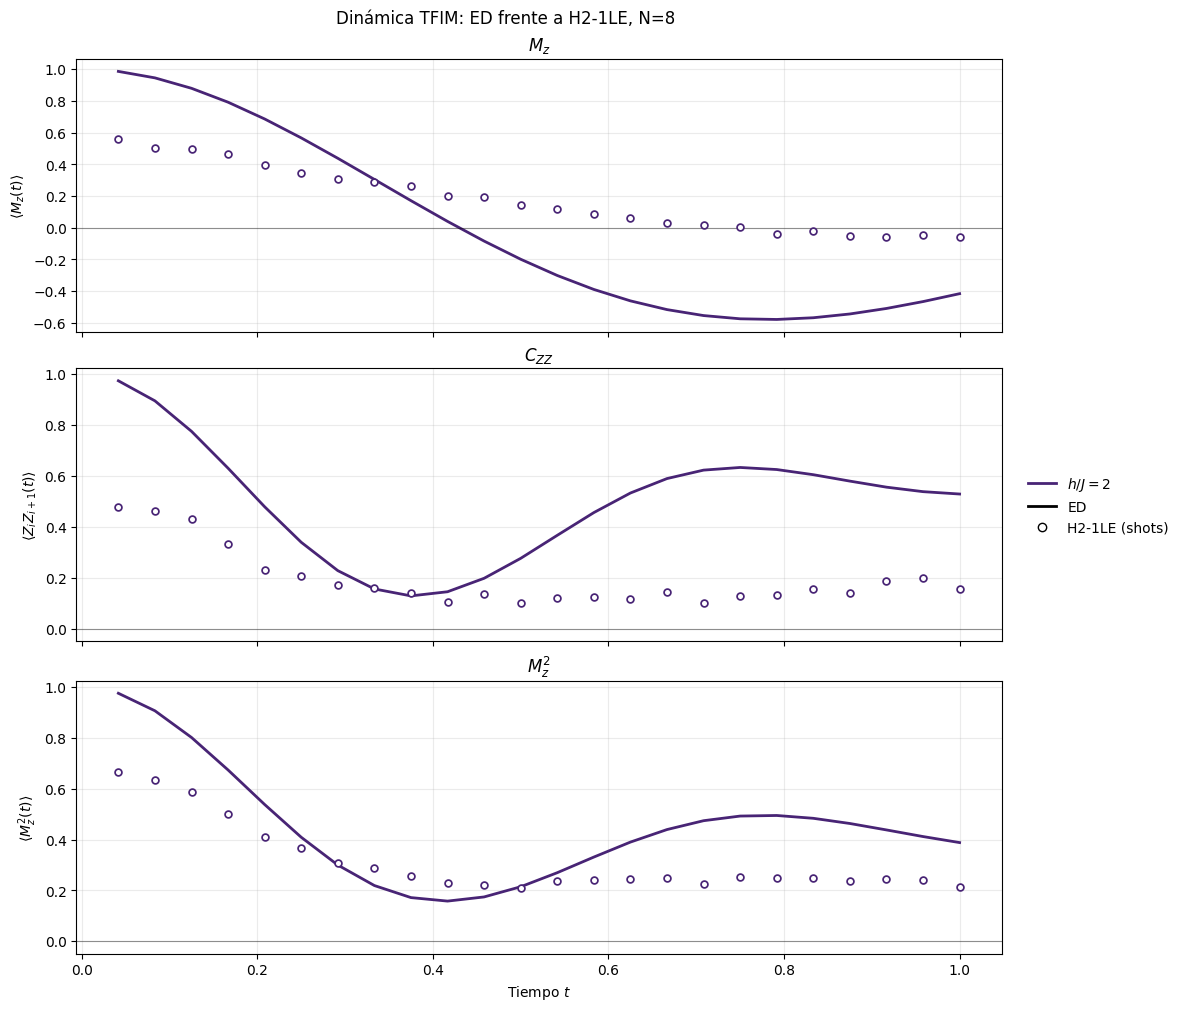

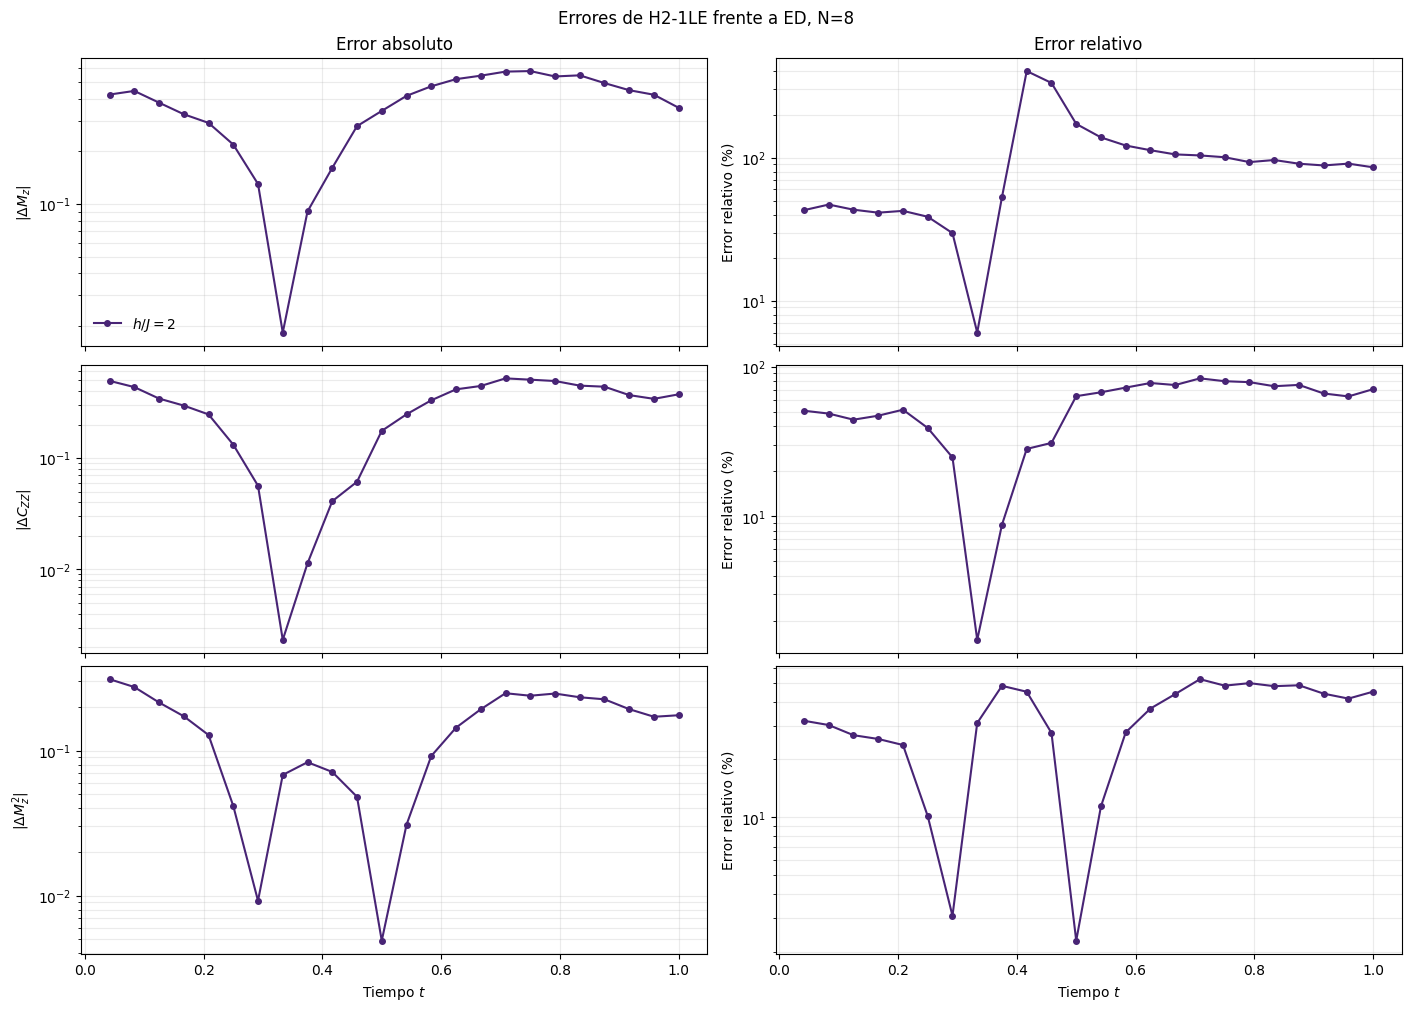

,h_over_J,time,observable,ed_value,h2_value,abs_error,relative_error_percent,standard_error
0,2.0,0.041667,mz,0.986169,0.562200,0.423970,42.991574,0.020510
1,2.0,0.041667,mz2,0.975964,0.665640,0.310324,31.796630,0.015283
2,2.0,0.041667,czz,0.972535,0.479396,0.493140,50.706607,0.025179
3,2.0,0.083333,mz,0.945363,0.500595,0.444769,47.047390,0.021337
4,2.0,0.083333,mz2,0.907005,0.633026,0.273979,30.206968,0.015061


In [86]:
from functools import lru_cache

import pandas as pd
from scipy.linalg import eigh


OBSERVABLE_KEYS = ("mz", "mz2", "czz")


@lru_cache(maxsize=None)
def exact_tfim_model(h: float, J: float, n: int):
    """Diagonaliza el TFIM abierto y construye observables diagonales en Z."""
    h = float(h)
    J = float(J)
    n = int(n)
    if n < 2:
        raise ValueError("CZZ requiere al menos dos qubits.")

    dimension = 2**n
    basis = np.arange(dimension, dtype=np.uint64)
    positions = np.arange(n, dtype=np.uint64)
    bits = ((basis[:, None] >> positions) & 1).astype(int)
    z_values = 1 - 2 * bits

    mz_values = np.mean(z_values, axis=1)
    mz2_values = mz_values**2
    czz_values = np.mean(
        z_values[:, :-1] * z_values[:, 1:],
        axis=1,
    )
    zz_sum = np.sum(
        z_values[:, :-1] * z_values[:, 1:],
        axis=1,
    )

    hamiltonian = np.diag(-J * zz_sum).astype(complex)
    rows = np.arange(dimension)
    for site in range(n):
        flipped = basis ^ np.uint64(1 << site)
        hamiltonian[rows, flipped.astype(int)] -= h

    eigenvalues, eigenvectors = eigh(hamiltonian)
    initial_state = np.zeros(dimension, dtype=complex)
    initial_state[0] = 1.0
    initial_coefficients = eigenvectors.conj().T @ initial_state

    observable_values = {
        "mz": mz_values,
        "mz2": mz2_values,
        "czz": czz_values,
    }
    return (
        eigenvalues,
        eigenvectors,
        initial_coefficients,
        observable_values,
    )


@lru_cache(maxsize=None)
def exact_reference_observables(
    h: float,
    J: float,
    t: float,
    n: int,
):
    (
        eigenvalues,
        eigenvectors,
        initial_coefficients,
        observable_values,
    ) = exact_tfim_model(float(h), float(J), int(n))

    phases = np.exp(-1j * eigenvalues * float(t))
    state = eigenvectors @ (phases * initial_coefficients)
    probabilities = np.abs(state) ** 2

    return {
        key: float(probabilities @ observable_values[key])
        for key in OBSERVABLE_KEYS
    }


def build_dynamics_dataframe(
    execution_records,
    hj_ratios,
    times,
    J: float,
    n: int,
):
    ratios, times, h2_values, standard_errors = (
        empirical_observables_grid(
            execution_records,
            hj_ratios,
            times,
            n,
        )
    )

    rows = []
    for ratio_index, ratio in enumerate(ratios):
        for time_index, time in enumerate(times):
            ed_values = exact_reference_observables(
                h=float(ratio * J),
                J=float(J),
                t=float(time),
                n=int(n),
            )
            for key in OBSERVABLE_KEYS:
                h2_value = float(
                    h2_values[key][ratio_index, time_index]
                )
                ed_value = ed_values[key]
                standard_error = float(
                    standard_errors[key][ratio_index, time_index]
                )
                abs_error = abs(h2_value - ed_value)
                relative_error = (
                    np.nan
                    if np.isclose(ed_value, 0.0, atol=1e-12, rtol=0.0)
                    else 100.0 * abs_error / abs(ed_value)
                )
                rows.append(
                    {
                        "h_over_J": float(ratio),
                        "time": float(time),
                        "observable": key,
                        "ed_value": ed_value,
                        "h2_value": h2_value,
                        "abs_error": abs_error,
                        "relative_error_percent": relative_error,
                        "standard_error": standard_error,
                    }
                )

    return pd.DataFrame(rows)


def graph_ed_and_h2_shots(dynamics_df, n: int):
    """ED como líneas y estimaciones de H2-1LE como puntos."""
    ratios = np.sort(dynamics_df["h_over_J"].unique())
    colors = plt.cm.viridis(
        np.linspace(0.1, 0.9, len(ratios))
    )
    figure, axes = plt.subplots(
        3,
        1,
        figsize=(10, 10),
        sharex=True,
        constrained_layout=True,
    )
    plot_specs = [
        ("mz", axes[0], r"$\langle M_z(t)\rangle$", r"$M_z$"),
        (
            "czz",
            axes[1],
            r"$\langle Z_iZ_{i+1}(t)\rangle$",
            r"$C_{ZZ}$",
        ),
        (
            "mz2",
            axes[2],
            r"$\langle M_z^2(t)\rangle$",
            r"$M_z^2$",
        ),
    ]

    for key, axis, ylabel, title in plot_specs:
        observable_data = dynamics_df[
            dynamics_df["observable"] == key
        ]
        for color, ratio in zip(colors, ratios):
            ratio_data = observable_data[
                np.isclose(observable_data["h_over_J"], ratio)
            ].sort_values("time")
            axis.plot(
                ratio_data["time"],
                ratio_data["ed_value"],
                color=color,
                linewidth=2,
            )
            axis.scatter(
                ratio_data["time"],
                ratio_data["h2_value"],
                s=24,
                facecolors="white",
                edgecolors=color,
                linewidths=1.25,
                zorder=3,
            )

        axis.set_ylabel(ylabel)
        axis.set_title(title)
        axis.axhline(0, color="black", linewidth=0.8, alpha=0.4)
        axis.grid(alpha=0.25)

    axes[-1].set_xlabel(r"Tiempo $t$")
    ratio_handles = [
        Line2D(
            [0],
            [0],
            color=color,
            linewidth=2,
            label=fr"$h/J={ratio:.3g}$",
        )
        for color, ratio in zip(colors, ratios)
    ]
    method_handles = [
        Line2D(
            [0],
            [0],
            color="black",
            linewidth=2,
            label="ED",
        ),
        Line2D(
            [0],
            [0],
            color="black",
            marker="o",
            markerfacecolor="white",
            linestyle="none",
            label="H2-1LE (shots)",
        ),
    ]
    figure.legend(
        handles=ratio_handles + method_handles,
        loc="center left",
        bbox_to_anchor=(1.01, 0.5),
        frameon=False,
    )
    figure.suptitle(
        f"Dinámica TFIM: ED frente a H2-1LE, N={n}"
    )
    return figure, axes


def graph_h2_errors(dynamics_df, n: int):
    """Grafica los errores absoluto y relativo de H2-1LE frente a ED."""
    ratios = np.sort(dynamics_df["h_over_J"].unique())
    colors = plt.cm.viridis(
        np.linspace(0.1, 0.9, len(ratios))
    )
    figure, axes = plt.subplots(
        3,
        2,
        figsize=(14, 10),
        sharex=True,
        constrained_layout=True,
    )
    plot_specs = [
        ("mz", r"M_z"),
        ("czz", r"C_{ZZ}"),
        ("mz2", r"M_z^2"),
    ]

    for row, (key, observable_label) in enumerate(plot_specs):
        absolute_axis = axes[row, 0]
        relative_axis = axes[row, 1]
        observable_data = dynamics_df[
            dynamics_df["observable"] == key
        ]
        for color, ratio in zip(colors, ratios):
            ratio_data = observable_data[
                np.isclose(observable_data["h_over_J"], ratio)
            ].sort_values("time")
            absolute_axis.semilogy(
                ratio_data["time"],
                np.maximum(
                    ratio_data["abs_error"],
                    np.finfo(float).tiny,
                ),
                color=color,
                marker="o",
                markersize=4,
                linewidth=1.5,
                label=fr"$h/J={ratio:.3g}$",
            )
            relative_axis.semilogy(
                ratio_data["time"],
                ratio_data["relative_error_percent"],
                color=color,
                marker="o",
                markersize=4,
                linewidth=1.5,
            )

        absolute_axis.set_ylabel(
            fr"$|\Delta {observable_label}|$"
        )
        relative_axis.set_ylabel("Error relativo (%)")
        absolute_axis.grid(True, which="both", alpha=0.25)
        relative_axis.grid(True, which="both", alpha=0.25)

    axes[0, 0].set_title("Error absoluto")
    axes[0, 1].set_title("Error relativo")
    axes[-1, 0].set_xlabel(r"Tiempo $t$")
    axes[-1, 1].set_xlabel(r"Tiempo $t$")
    axes[0, 0].legend(frameon=False, ncol=3)
    figure.suptitle(
        f"Errores de H2-1LE frente a ED, N={n}"
    )
    return figure, axes


dynamics_df = build_dynamics_dataframe(
    execution_records=execution_records,
    hj_ratios=hj_ratios,
    times=times_simulator,
    J=J,
    n=n_qbits,
)
dynamics_csv_path = Path.cwd() / "h2_dynamics_observables.csv"
dynamics_df.to_csv(dynamics_csv_path, index=False)

dynamics_figure, dynamics_axes = graph_ed_and_h2_shots(
    dynamics_df,
    n=n_qbits,
)
plt.show()

dynamics_error_figure, dynamics_error_axes = (
    graph_h2_errors(
        dynamics_df,
        n=n_qbits,
    )
)
plt.show()

dynamics_df.head()
